# Notebook hoạt động Hồi quy tuyến tính (Linear Regression)

Notebook này đi cùng tài liệu **Hướng dẫn hoạt động Hồi quy tuyến tính**.  
Mục tiêu là giúp sinh viên hiểu cả **toán học**, **trực quan hóa**, và **ý nghĩa mô hình**.

Quy ước thuật ngữ: tiếng Việt được ưu tiên, thuật ngữ tiếng Anh và viết tắt được đặt trong ngoặc ở lần đầu hoặc khi cần nhắc lại. Ví dụ: **hệ số dốc (slope)**, **hệ số chặn (intercept)**, **phương pháp bình phương tối thiểu thông thường (Ordinary Least Squares - OLS)**.


## Bảng thuật ngữ nhanh trước khi chạy code

| Ký hiệu / thuật ngữ | Cách đọc trong notebook | Ý nghĩa |
|---|---|---|
| $x$ | biến giải thích (explanatory variable / predictor) | Biến dùng để dự báo hoặc giải thích $y$. |
| $y$ | biến mục tiêu (target / response variable) | Biến cần dự báo hoặc giải thích. |
| $\beta_0$ | hệ số chặn (intercept) | Giá trị kỳ vọng của $y$ khi $x=0$. |
| $\beta_1$ | hệ số dốc (slope) | Mức thay đổi trung bình của $y$ khi $x$ tăng 1 đơn vị. |
| $\hat{y}$ | giá trị khớp / giá trị dự báo (fitted value / prediction) | Giá trị mô hình dự báo. |
| $e = y - \hat{y}$ | phần dư (residual) | Sai lệch giữa giá trị thật và giá trị dự báo. |
| OLS | phương pháp bình phương tối thiểu thông thường (Ordinary Least Squares) | Chọn hệ số sao cho tổng bình phương phần dư nhỏ nhất. |
| RSS/SSE | tổng bình phương phần dư (Residual Sum of Squares) / tổng bình phương sai số (Sum of Squared Errors) | $\sum e_i^2$. |
| RMSE - căn sai số bình phương trung bình (Root Mean Squared Error) | căn sai số bình phương trung bình (Root Mean Squared Error) | Thước đo lỗi cùng đơn vị với $y$, nhạy với lỗi lớn. |
| MAE - sai số tuyệt đối trung bình (Mean Absolute Error) | sai số tuyệt đối trung bình (Mean Absolute Error) | Trung bình $|e_i|$, dễ giải thích. |
| $R^2$ | hệ số xác định (Coefficient of Determination) | Tỷ lệ biến thiên của $y$ được mô hình giải thích. |


In [1]:
# =========================
# 0. Khởi tạo môi trường
# =========================

# numpy: tính toán số học và đại số tuyến tính (linear algebra)
# pandas: thao tác bảng dữ liệu (data frame)
# matplotlib: vẽ biểu đồ / trực quan hóa dữ liệu (visualization)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
try:
    from IPython.display import display
except Exception:
    display = print

# Tìm thư mục dữ liệu một cách linh hoạt để notebook chạy được khi đặt trong /notebooks
candidate_dirs = [Path('../datasets'), Path('datasets'), Path('/mnt/data/linear_regression_activity_pack/datasets')]
DATA_DIR = next((p for p in candidate_dirs if p.exists()), candidate_dirs[0])
print('DATA_DIR =', DATA_DIR.resolve())

from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV, HuberRegressor, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score, KFold

plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['figure.max_open_warning'] = 100
np.set_printoptions(precision=4, suppress=True)


def make_one_hot(drop='first'):
    """Tạo OneHotEncoder tương thích nhiều phiên bản scikit-learn."""
    try:
        return OneHotEncoder(drop=drop, sparse_output=False)
    except TypeError:
        return OneHotEncoder(drop=drop, sparse=False)

DATA_DIR = D:\linear_regression_activity_pack_viet_hoa_v2_professional\linear_regression_activity_pack\datasets


## Hàm tiện ích (Utility functions)

Các hàm dưới đây được dùng lặp lại trong nhiều hoạt động.

- **RMSE - căn sai số bình phương trung bình (Root Mean Squared Error) (Root Mean Squared Error)**: phạt lỗi lớn mạnh vì bình phương sai số.
- **MAE - sai số tuyệt đối trung bình (Mean Absolute Error) (Mean Absolute Error)**: dễ diễn giải hơn vì cùng đơn vị với biến mục tiêu.
- **hệ số xác định R² (Coefficient of Determination) (Coefficient of Determination)**: phần biến thiên của `y` được mô hình giải thích, nhưng không chứng minh nhân quả.

In [2]:
def regression_metrics(y_true, y_pred):
    """
    Tính các thước đo hồi quy (regression metrics).

    Thuật ngữ:
    - RMSE: căn sai số bình phương trung bình (Root Mean Squared Error)
    - MAE: sai số tuyệt đối trung bình (Mean Absolute Error)
    - R2: hệ số xác định (Coefficient of Determination)

    y_true: giá trị thật
    y_pred: giá trị dự báo y_hat

    Công thức:
        RMSE = sqrt(mean((y - y_hat)^2))
        MAE  = mean(|y - y_hat|)
        R2   = 1 - SSE/SST, trong đó SSE/RSS là tổng bình phương phần dư
    """
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2}


def plot_residuals(x_or_fitted, residuals, xlabel='Giá trị dự báo (fitted values)', title='Biểu đồ phần dư (Residual plot)'):
    """
    Residual plot giúp phát hiện:
    - quan hệ phi tuyến (curved pattern),
    - phương sai thay đổi (fan shape),
    - outlier/influential point.
    """
    plt.figure()
    plt.scatter(x_or_fitted, residuals, alpha=0.75)
    plt.axhline(0, linestyle='--')
    plt.xlabel(xlabel)
    plt.ylabel('Phần dư e = y - y_hat')
    plt.title(title)
    plt.show()


def actual_vs_predicted(y_true, y_pred, title='Thực tế vs Dự báo (Actual vs Predicted)'):
    """Điểm càng gần đường 45 độ thì dự báo càng tốt."""
    plt.figure()
    plt.scatter(y_true, y_pred, alpha=0.75)
    lo = min(np.min(y_true), np.min(y_pred))
    hi = max(np.max(y_true), np.max(y_pred))
    plt.plot([lo, hi], [lo, hi], linestyle='--')
    plt.xlabel('Giá trị thật (actual)')
    plt.ylabel('Giá trị dự báo (predicted)')
    plt.title(title)
    plt.show()

# Hoạt động 1 - Hồi quy tuyến tính đơn bằng tay (Simple Linear Regression by Hand)

Bối cảnh: dự báo điểm thi (`exam_score`) từ số giờ học (`study_hours`).

Mô hình:

$$y_i = \beta_0 + \beta_1x_i + \varepsilon_i$$

Trong đó:

- $\beta_0$: hệ số chặn (intercept), giá trị kỳ vọng của y khi x = 0.
- $\beta_1$: hệ số dốc (slope), mức thay đổi trung bình của y khi x tăng 1 đơn vị.
- $\varepsilon_i$: sai số ngẫu nhiên (random error).

Ước lượng bằng OLS - phương pháp bình phương tối thiểu thông thường (Ordinary Least Squares) cho SLR:

$$\hat{\beta}_1 = \frac{\sum_i(x_i-\bar{x})(y_i-\bar{y})}{\sum_i(x_i-\bar{x})^2}$$

$$\hat{\beta}_0 = \bar{y} - \hat{\beta}_1\bar{x}$$

In [3]:
df = pd.read_csv(DATA_DIR / 'activity_01_slr_hand_calculation.csv')
df.head()

,student_id,study_hours,exam_score
0,1,1.0,51.0
1,2,2.0,55.0
2,3,2.5,57.0
3,4,3.0,61.0
4,5,3.5,64.0


In [4]:
# Chuyển cột thành mảng numpy để tính toán công thức dễ hơn.
x = df['study_hours'].to_numpy()
y = df['exam_score'].to_numpy()

# Trung bình mẫu (sample mean)
xbar = x.mean()
ybar = y.mean()

# Các độ lệch so với trung bình.
# Ý nghĩa: nếu x và y cùng cao hơn trung bình thì tích này dương; nếu ngược chiều thì âm.
x_centered = x - xbar
y_centered = y - ybar

# Công thức hệ số dốc (slope): covariance(x,y) / variance(x).
# Hệ số dốc cho biết y thay đổi trung bình bao nhiêu khi x tăng 1 đơn vị.
beta1 = np.sum(x_centered * y_centered) / np.sum(x_centered**2)

# Công thức hệ số chặn (intercept): đường hồi quy OLS đi qua điểm trung bình (xbar, ybar).
beta0 = ybar - beta1 * xbar

print(f'xbar = {xbar:.3f}, ybar = {ybar:.3f}')
print(f'beta0_hat / hệ số chặn (intercept) = {beta0:.3f}')
print(f'beta1_hat / hệ số dốc (slope)     = {beta1:.3f}')

# Bảng tính trung gian để sinh viên kiểm tra bằng tay/Excel
manual_table = pd.DataFrame({
    'x': x,
    'y': y,
    'x_minus_xbar': x_centered,
    'y_minus_ybar': y_centered,
    'cross_product': x_centered * y_centered,
    'x_squared_dev': x_centered**2
})
manual_table.head()

xbar = 4.625, ybar = 68.917
beta0_hat / hệ số chặn (intercept) = 45.701
beta1_hat / hệ số dốc (slope)     = 5.020


,x,y,x_minus_xbar,y_minus_ybar,cross_product,x_squared_dev
0,1.0,51.0,-3.625,-17.916667,64.947917,13.140625
1,2.0,55.0,-2.625,-13.916667,36.531250,6.890625
2,2.5,57.0,-2.125,-11.916667,25.322917,4.515625
3,3.0,61.0,-1.625,-7.916667,12.864583,2.640625
4,3.5,64.0,-1.125,-4.916667,5.531250,1.265625


In [5]:
# Giá trị khớp / giá trị dự báo (fitted value): y_hat_i = beta0_hat + beta1_hat * x_i
yhat = beta0 + beta1 * x

# Phần dư (residual): e_i = y_i - y_hat_i
# Phần dư dương: mô hình dự báo thấp hơn giá trị thật.
# Phần dư âm: mô hình dự báo cao hơn giá trị thật.
resid = y - yhat

SSE = np.sum(resid**2)              # tổng bình phương sai số/phần dư (Sum of Squared Errors - SSE), còn gọi gần tương đương RSS
MSE_unbiased = SSE / (len(y) - 2)   # dùng n-2 vì SLR ước lượng 2 tham số
RMSE = np.sqrt(np.mean(resid**2))   # phiên bản dự báo thường dùng chia n
MAE = np.mean(np.abs(resid))
SST = np.sum((y - ybar)**2)
R2 = 1 - SSE/SST

print(f'SSE/RSS = tổng bình phương phần dư = {SSE:.3f}')
print(f'MSE = sai số bình phương trung bình (chia n-2 cho ước lượng phương sai) = {MSE_unbiased:.3f}')
print(f'RMSE = căn sai số bình phương trung bình = {RMSE:.3f}')
print(f'MAE = sai số tuyệt đối trung bình = {MAE:.3f}')
print(f'R2 = hệ số xác định = {R2:.3f}')

SSE/RSS = tổng bình phương phần dư = 5.203
MSE = sai số bình phương trung bình (chia n-2 cho ước lượng phương sai) = 0.520
RMSE = căn sai số bình phương trung bình = 0.659
MAE = sai số tuyệt đối trung bình = 0.526
R2 = hệ số xác định = 0.997


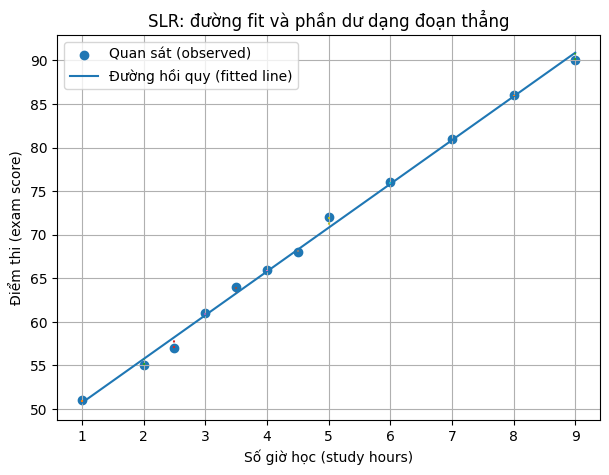

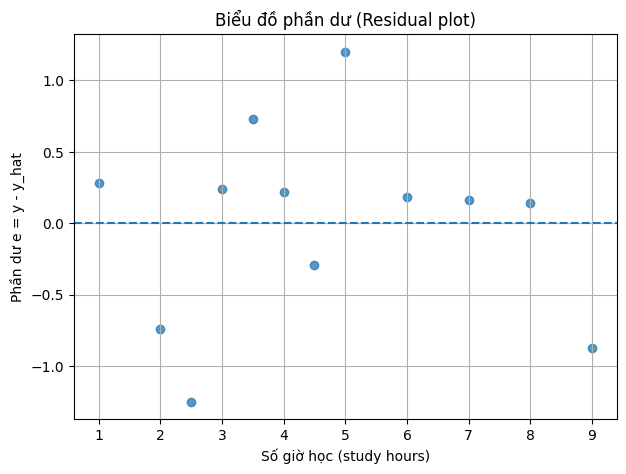

In [6]:
# Trực quan hóa (visualization) 1: scatter plot + fitted line + residual sticks
plt.figure()
plt.scatter(x, y, label='Quan sát (observed)')
plt.plot(x, yhat, label='Đường hồi quy (fitted line)')
for xi, yi, yhi in zip(x, y, yhat):
    # đoạn thẳng từ điểm thật đến đường hồi quy chính là residual stick
    plt.plot([xi, xi], [yi, yhi], linestyle=':')
plt.xlabel('Số giờ học (study hours)')
plt.ylabel('Điểm thi (exam score)')
plt.title('SLR: đường fit và phần dư dạng đoạn thẳng')
plt.legend()
plt.show()

# Trực quan hóa (visualization) 2: residual plot
plot_residuals(x, resid, xlabel='Số giờ học (study hours)')

**Câu hỏi thảo luận**

1. Nếu slope khoảng 5, có thể nói “học thêm 1 giờ làm điểm tăng 5 điểm” không? Điều kiện nào cần để nói nhân quả?
2. Intercept có ý nghĩa thực tế không nếu dữ liệu không chứa sinh viên học 0 giờ?
3. Quan sát nào có phần dư lớn nhất? Có nên xem lại dữ liệu đó không?

# Hoạt động 2 - OLS như tối ưu hóa (Optimization) và hình học (Geometry)

Hàm mục tiêu của OLS là tổng bình phương phần dư (Residual Sum of Squares - RSS):

$$RSS(\beta_0,\beta_1)=\sum_{i=1}^{n}(y_i-\beta_0-\beta_1x_i)^2$$

OLS chọn cặp $(\hat\beta_0, \hat\beta_1)$ làm RSS nhỏ nhất:

$$ (\hat\beta_0,\hat\beta_1)=\arg\min_{\beta_0,\beta_1} RSS(\beta_0,\beta_1) $$

### Đọc công thức OLS và RSS bằng lời

**Phương pháp bình phương tối thiểu thông thường (Ordinary Least Squares - OLS)** không “tự nhiên biết” đường nào tốt nhất. OLS định nghĩa một tiêu chuẩn: chọn đường làm **tổng bình phương phần dư (Residual Sum of Squares - RSS)** nhỏ nhất.

$$RSS(\beta_0,\beta_1)=\sum_i (y_i-\beta_0-\beta_1x_i)^2$$

Trong code bên dưới, mỗi cặp `b0`, `b1` tương ứng với một đường thẳng. Ta tính RSS cho từng đường, rồi tìm đường có RSS nhỏ nhất.


In [7]:
df = pd.read_csv(DATA_DIR / 'activity_02_ols_geometry_gradient.csv')
df.head()

,x,y,true_mean
0,0.000000,19.986857,18.000000
1,0.126582,17.978588,18.531646
2,0.253165,21.654045,19.063291
3,0.379747,25.687056,19.594937
4,0.506329,19.189969,20.126582


In [8]:
x = df['x'].to_numpy()
y = df['y'].to_numpy()

# Nghiệm đóng (closed-form solution) cho hồi quy tuyến tính đơn (Simple Linear Regression - SLR)
beta1_closed = np.sum((x-x.mean())*(y-y.mean())) / np.sum((x-x.mean())**2)
beta0_closed = y.mean() - beta1_closed*x.mean()
print(f'Nghiệm đóng: beta0 / hệ số chặn (intercept) = {beta0_closed:.3f}, beta1 / hệ số dốc (slope) = {beta1_closed:.3f}')

Nghiệm đóng: beta0 / hệ số chặn (intercept) = 17.315, beta1 / hệ số dốc (slope) = 4.238


Grid minimum: 17.478991596638657 4.235294117647059 1159.6479637635239


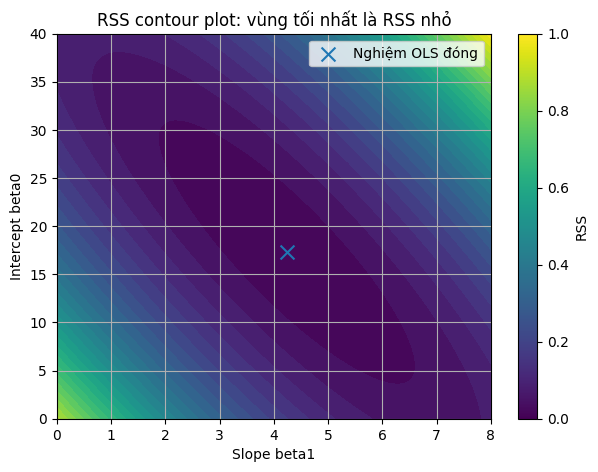

In [9]:
# Tìm kiếm lưới (grid search): thử rất nhiều cặp beta0, beta1 rồi chọn RSS nhỏ nhất.
# RSS = tổng bình phương phần dư (Residual Sum of Squares) = sum((y - y_hat)^2).
# Cách này trực quan nhưng không hiệu quả khi số biến lớn.
b0_grid = np.linspace(0, 40, 120)
b1_grid = np.linspace(0, 8, 120)
RSS = np.zeros((len(b0_grid), len(b1_grid)))

for i, b0 in enumerate(b0_grid):
    for j, b1 in enumerate(b1_grid):
        yhat_grid = b0 + b1*x
        RSS[i, j] = np.sum((y - yhat_grid)**2)

min_idx = np.unravel_index(np.argmin(RSS), RSS.shape)
print('Grid minimum:', b0_grid[min_idx[0]], b1_grid[min_idx[1]], RSS[min_idx])

plt.figure()
plt.contourf(b1_grid, b0_grid, RSS, levels=30)
plt.scatter([beta1_closed], [beta0_closed], marker='x', s=100, label='Nghiệm OLS đóng')
plt.xlabel('Slope beta1')
plt.ylabel('Intercept beta0')
plt.title('RSS contour plot: vùng tối nhất là RSS nhỏ')
plt.legend()
plt.colorbar(label='RSS')
plt.show()

## Hạ dốc (Gradient Descent)

Đạo hàm của RSS:

$$\frac{\partial RSS}{\partial \beta_0}=-2\sum_i(y_i-\beta_0-\beta_1x_i)$$

$$\frac{\partial RSS}{\partial \beta_1}=-2\sum_i x_i(y_i-\beta_0-\beta_1x_i)$$

Ý tưởng: cập nhật tham số theo hướng ngược gradient để giảm RSS.

In [10]:
# Demo gradient descent đơn giản.
# lr (learning rate) quá nhỏ: học chậm. Quá lớn: có thể không hội tụ.
b0, b1 = 0.0, 0.0
lr = 0.00002
history = []

for step in range(2500):
    yhat = b0 + b1*x
    error = y - yhat
    grad_b0 = -2*np.sum(error)
    grad_b1 = -2*np.sum(x*error)
    b0 -= lr * grad_b0
    b1 -= lr * grad_b1
    if step % 50 == 0:
        rss = np.sum(error**2)
        history.append((step, b0, b1, rss))

hist = pd.DataFrame(history, columns=['step', 'beta0', 'beta1', 'rss'])
hist.tail()

,step,beta0,beta1,rss
45,2250,14.606580,4.644634,1307.614887
46,2300,14.712480,4.628731,1296.132047
47,2350,14.814239,4.613450,1285.529471
48,2400,14.912021,4.598766,1275.739678
49,2450,15.005979,4.584656,1266.700360


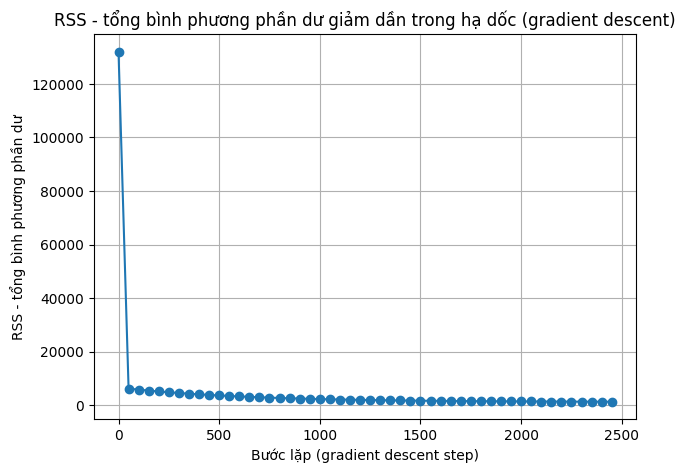

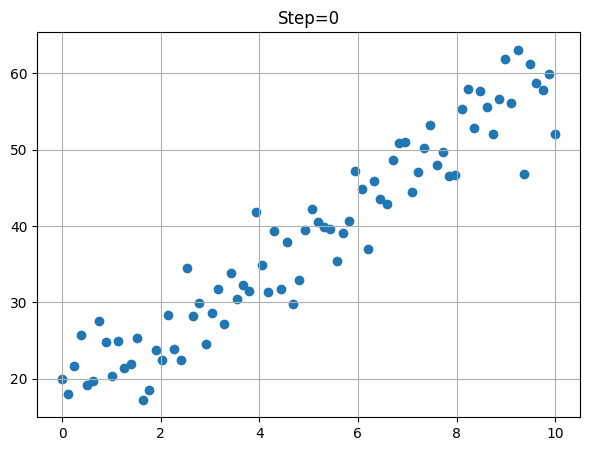

In [11]:
plt.figure()
plt.plot(hist['step'], hist['rss'], marker='o')
plt.xlabel('Bước lặp (gradient descent step)')
plt.ylabel('RSS - tổng bình phương phần dư')
plt.title('RSS - tổng bình phương phần dư giảm dần trong hạ dốc (gradient descent)')
plt.show()

# Optional animation: nếu chạy trong Jupyter, bỏ comment các dòng dưới.
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
fig, ax = plt.subplots()
ax.scatter(x, y)
line, = ax.plot([], [])
def update(frame):
    b0_t, b1_t = hist.loc[frame, ['beta0','beta1']]
    xline = np.linspace(x.min(), x.max(), 100)
    line.set_data(xline, b0_t + b1_t*xline)
    ax.set_title(f'Step={int(hist.loc[frame, "step"])}')
    return line,
anim = FuncAnimation(fig, update, frames=len(hist), interval=120)
HTML(anim.to_jshtml())

# Hoạt động 3 - Khi SLR thất bại (Failure Modes and Diagnostics)

SLR có thể cho hệ số và hệ số xác định R² (Coefficient of Determination) nhìn có vẻ ổn nhưng vẫn sai mô hình. Ta kiểm tra bằng visualization:

- **Linearity**: residual plot không nên có dạng cong rõ ràng.
- **Constant variance / Homoscedasticity**: độ phân tán residual tương đối đều.
- **Outliers and influence**: điểm xa có thể kéo đường hồi quy.
- **Structural break**: quan hệ thay đổi sau một ngưỡng.

In [12]:
df = pd.read_csv(DATA_DIR / 'activity_03_slr_failures_diagnostics.csv')
df.head()

,x,y_linear_ok,y_nonlinear_pattern,y_heteroscedastic,y_influential_outliers,y_structural_break
0,0.000000,9.516722,30.414959,10.724458,10.579550,15.554043
1,0.062893,10.974327,31.333836,11.688446,14.339481,12.016037
2,0.125786,13.628725,32.143711,12.381916,12.119608,12.761945
3,0.188679,9.425843,32.442796,12.608498,9.913991,16.620894
4,0.251572,8.976031,27.895361,12.332391,13.157145,15.684916



 y_linear_ok {'RMSE': np.float64(2.1349642560248143), 'MAE': 1.6614042066660744, 'R2': 0.9446632322282682}


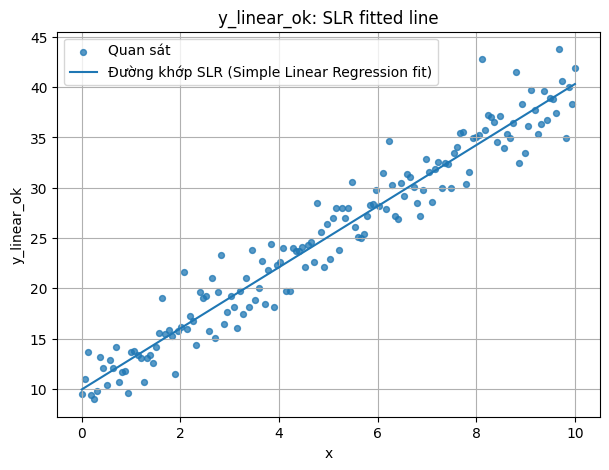

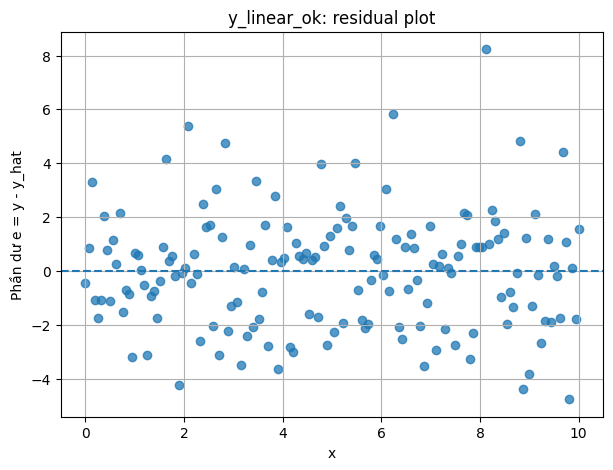


 y_nonlinear_pattern {'RMSE': np.float64(7.011066748337236), 'MAE': 5.932178041936288, 'R2': 0.4167695664846087}


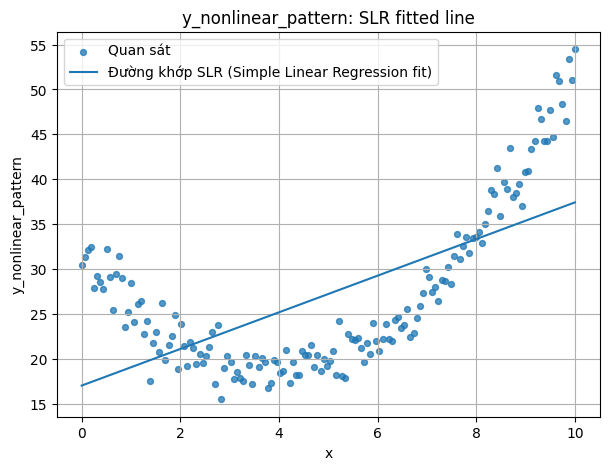

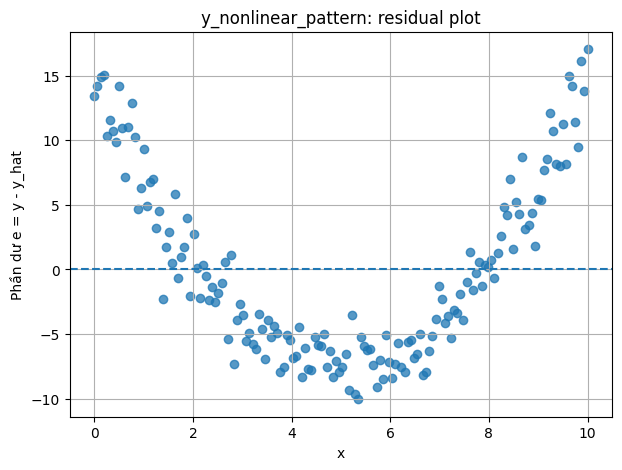


 y_heteroscedastic {'RMSE': np.float64(3.571679580029751), 'MAE': 2.701575179635169, 'R2': 0.8437675770791887}


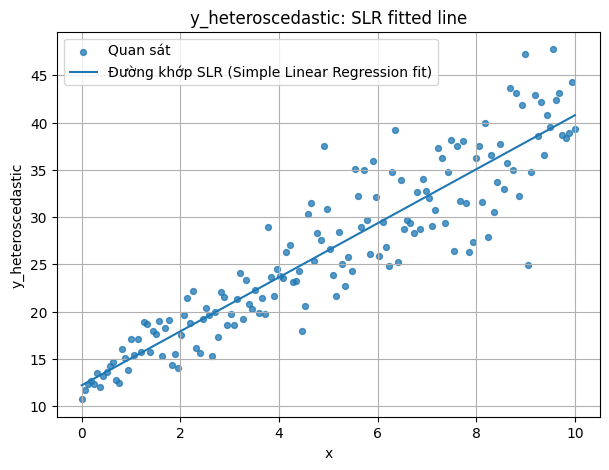

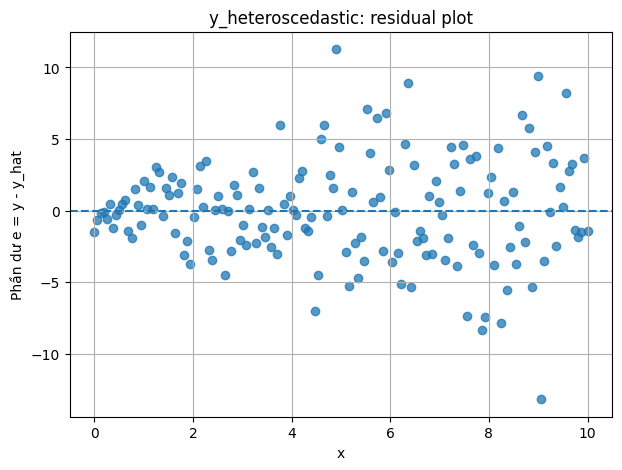


 y_influential_outliers {'RMSE': np.float64(6.072489474973373), 'MAE': 2.5789031289411826, 'R2': 0.7193994686446856}


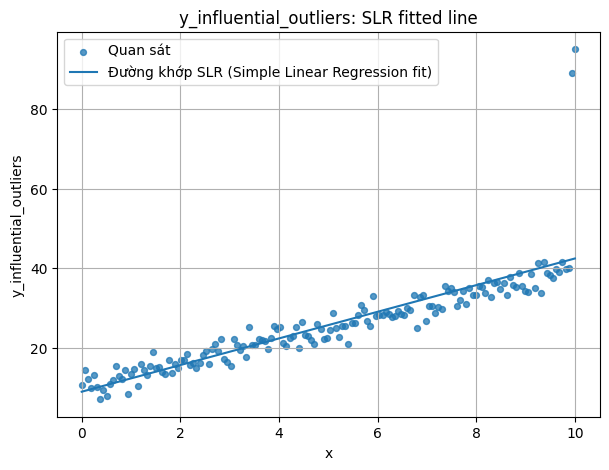

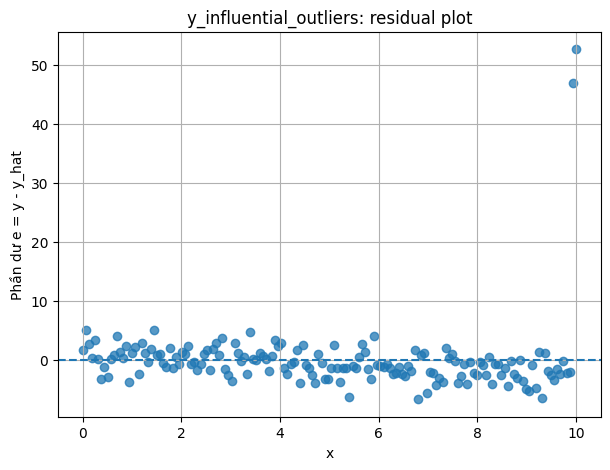


 y_structural_break {'RMSE': np.float64(2.6521246721121994), 'MAE': 2.1496727326183427, 'R2': 0.9336124303260537}


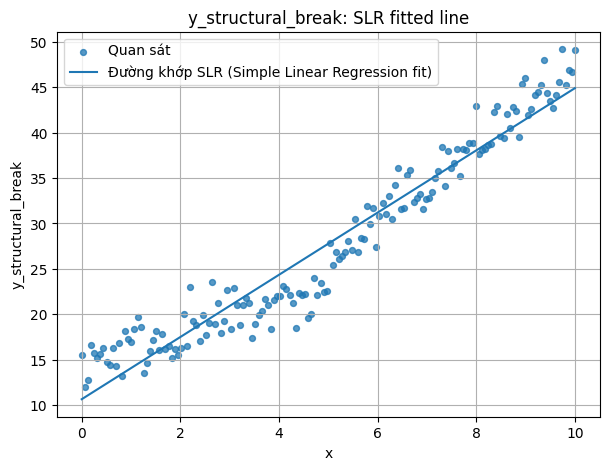

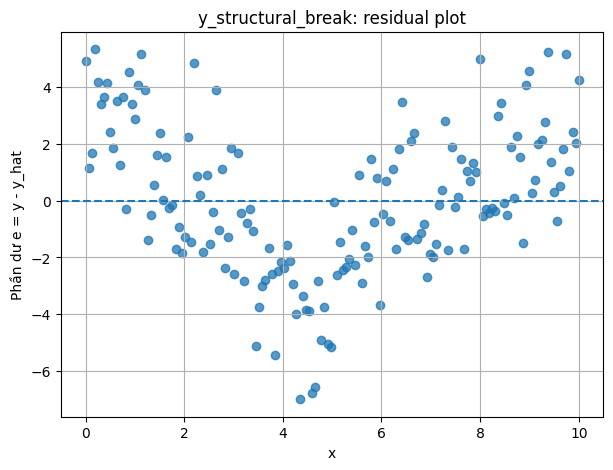

In [13]:
X = df[['x']]
outcomes = [c for c in df.columns if c.startswith('y_')]

for outcome in outcomes:
    model = LinearRegression().fit(X, df[outcome])
    pred = model.predict(X)
    resid = df[outcome] - pred
    print('\n', outcome, regression_metrics(df[outcome], pred))

    plt.figure()
    plt.scatter(df['x'], df[outcome], s=18, alpha=0.75, label='Quan sát')
    plt.plot(df['x'], pred, label='Đường khớp SLR (Simple Linear Regression fit)')
    plt.title(f'{outcome}: SLR fitted line')
    plt.xlabel('x')
    plt.ylabel(outcome)
    plt.legend()
    plt.show()

    plot_residuals(df['x'], resid, xlabel='x', title=f'{outcome}: residual plot')

**Bảng chẩn đoán nhanh**

| Dấu hiệu trên plot | Chẩn đoán có thể | Cách xử lý có thể thử |
|---|---|---|
| Residual cong | Phi tuyến (nonlinearity) | Polynomial, spline, log transform |
| Residual hình phễu | Phương sai thay đổi (heteroscedasticity) | Transform y, WLS, robust standard errors |
| Một điểm kéo slope mạnh | Influential point | Kiểm tra dữ liệu, robust regression, báo cáo sensitivity |
| Hai cụm có slope khác nhau | Structural break | Piecewise regression, interaction với segment |

# Hoạt động 4 - Hồi quy tuyến tính bội (Multiple Linear Regression - MLR)

Mô hình:

$$y = \beta_0 + \beta_1x_1 + \beta_2x_2 + \cdots + \beta_px_p + \varepsilon$$

Dạng ma trận:

$$\mathbf{y}=\mathbf{X}\boldsymbol{\beta}+\boldsymbol{\varepsilon}$$

$$\hat{\boldsymbol{\beta}}=(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$$

Diễn giải hệ số: $\beta_j$ là thay đổi trung bình của y khi $x_j$ tăng 1 đơn vị, **giữ các biến khác không đổi (holding other variables constant)**.

In [14]:
df = pd.read_csv(DATA_DIR / 'activity_04_multiple_regression_housing.csv')
df.head()

,property_id,size_sqft,bedrooms,bathrooms,age_years,distance_to_cbd_km,neighborhood,renovated,energy_rating,price_k_usd
0,1,1085,2,1.5,25.2,12.50,Central,0,C,356.9
1,2,1346,2,2.0,29.9,7.41,South,0,A,333.1
2,3,2041,4,2.5,12.8,9.71,Central,0,A,672.8
3,4,1581,2,1.5,7.7,10.49,Central,0,B,540.6
4,5,1886,5,3.5,13.4,0.98,Central,0,B,745.1


Train: {'RMSE': np.float64(38.95014998385662), 'MAE': 31.284191899758305, 'R2': 0.8957789810303294}
Test: {'RMSE': np.float64(38.02072065439319), 'MAE': 29.444567849926358, 'R2': 0.92521654525852}


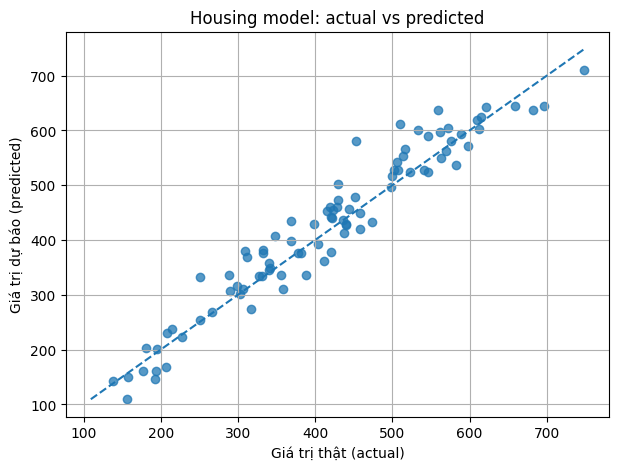

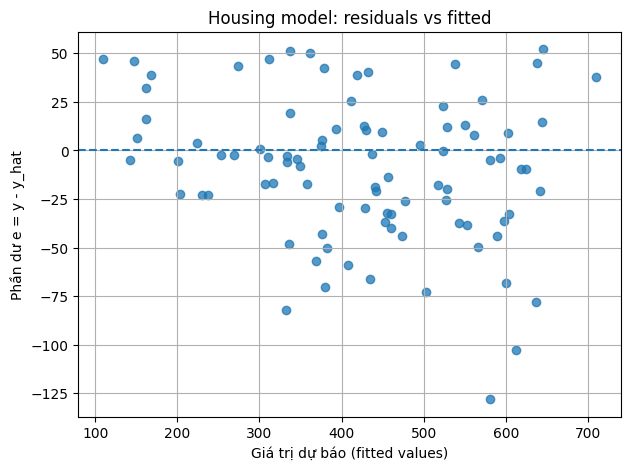

In [15]:
target = 'price_k_usd'
num_features = ['size_sqft', 'bedrooms', 'bathrooms', 'age_years', 'distance_to_cbd_km', 'renovated']
cat_features = ['neighborhood', 'energy_rating']

X = df[num_features + cat_features]
y = df[target]

# ColumnTransformer giúp xử lý biến số và biến phân loại trong cùng pipeline.
# StandardScaler: chuẩn hóa biến số để coefficient ổn định hơn trong một số mô hình.
# OneHotEncoder(drop='first'): tạo dummy variables và bỏ một nhóm làm reference category.
preprocess = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', make_one_hot(drop='first'), cat_features)
])

model = Pipeline([
    ('preprocess', preprocess),
    ('regression', LinearRegression())
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
model.fit(X_train, y_train)
pred_train = model.predict(X_train)
pred_test = model.predict(X_test)

print('Train:', regression_metrics(y_train, pred_train))
print('Test:', regression_metrics(y_test, pred_test))
actual_vs_predicted(y_test, pred_test, title='Housing model: actual vs predicted')
plot_residuals(pred_test, y_test - pred_test, title='Housing model: residuals vs fitted')

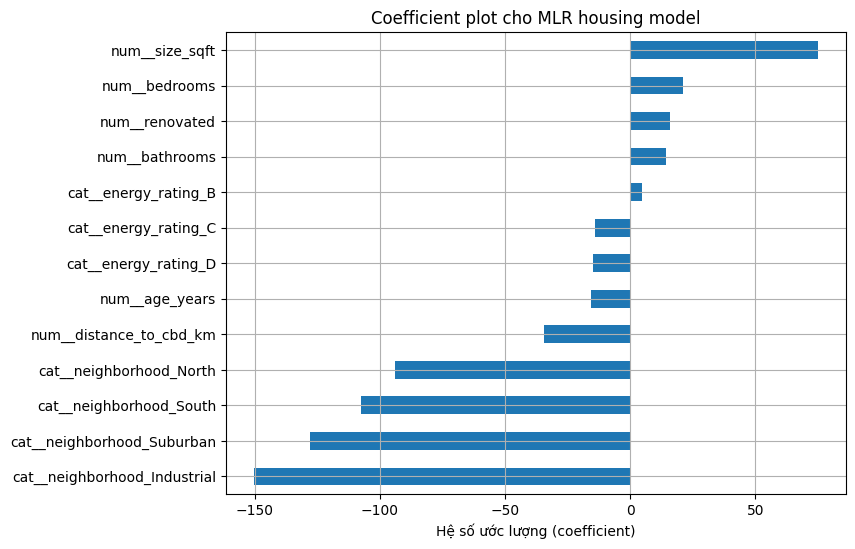

cat__neighborhood_North   -93.956577
num__distance_to_cbd_km   -34.255712
num__age_years            -15.740451
cat__energy_rating_D      -15.001237
cat__energy_rating_C      -13.859260
cat__energy_rating_B        4.721658
num__bathrooms             14.340967
num__renovated             15.862317
num__bedrooms              21.315187
num__size_sqft             74.953382
dtype: float64

In [16]:
# Biểu đồ hệ số (coefficient plot): lấy tên biến sau preprocessing để diễn giải hệ số.
feature_names = list(model.named_steps['preprocess'].get_feature_names_out())
coefs = pd.Series(model.named_steps['regression'].coef_, index=feature_names).sort_values()

plt.figure(figsize=(8, 6))
coefs.plot(kind='barh')
plt.title('Coefficient plot cho MLR housing model')
plt.xlabel('Hệ số ước lượng (coefficient)')
plt.show()

coefs.tail(10)

# Hoạt động 5 - Suy luận thống kê (Statistical Inference)

Các thư viện machine learning thường tập trung vào prediction. Để xem standard errors, p-values và confidence intervals, dùng `statsmodels` nếu có.

Nhắc lại với SLR:

$$s=\sqrt{\frac{SSE}{n-2}}$$

$$SE(\hat\beta_1)=\frac{s}{\sqrt{\sum_i(x_i-\bar{x})^2}}$$

$$t=\frac{\hat\beta_1-0}{SE(\hat\beta_1)}$$

In [17]:
# Optional: dùng statsmodels để xem bảng inference.
try:
    import statsmodels.formula.api as smf
    simple_sm = smf.ols('price_k_usd ~ size_sqft + bedrooms + bathrooms + age_years + distance_to_cbd_km + C(neighborhood) + C(energy_rating)', data=df).fit()
    print(simple_sm.summary())
    print('\n95% confidence intervals:')
    display(simple_sm.conf_int())
except Exception as e:
    print('statsmodels chưa sẵn sàng hoặc có lỗi:', e)
    print('Bạn vẫn có thể dạy inference bằng công thức SLR ở markdown phía trên.')

                            OLS Regression Results                            
Dep. Variable:            price_k_usd   R-squared:                       0.896
Model:                            OLS   Adj. R-squared:                  0.892
Method:                 Least Squares   F-statistic:                     248.1
Date:                Tue, 05 May 2026   Prob (F-statistic):          4.54e-162
Time:                        02:24:36   Log-Likelihood:                -1845.8
No. Observations:                 360   AIC:                             3718.
Df Residuals:                     347   BIC:                             3768.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

,0,1
Intercept,203.134033,252.476076
C(neighborhood)[T.Industrial],-166.045558,-133.786591
C(neighborhood)[T.North],-102.159318,-74.269939
C(neighborhood)[T.South],-122.677853,-95.397636
C(neighborhood)[T.Suburban],-138.827110,-113.127608
C(energy_rating)[T.B],-10.994954,16.341727
C(energy_rating)[T.C],-29.419758,-1.918170
C(energy_rating)[T.D],-38.882673,-6.807176
size_sqft,0.169431,0.198657
bedrooms,15.651717,30.822532


# Hoạt động 6 - Dự báo, train/test split và cross-validation

Mục tiêu ở đây là đánh giá khả năng tổng quát hóa (generalization) trên dữ liệu chưa thấy.

- **Training error**: lỗi trên dữ liệu dùng để học.
- **Test error**: lỗi trên dữ liệu không dùng khi fit model.
- **Cross-validation**: chia nhiều fold để ước lượng hiệu năng ổn định hơn.

In [18]:
# So sánh mô hình đơn giản và mô hình giàu biến bằng cross-validation.
features_simple = ['size_sqft']
features_medium = ['size_sqft', 'bedrooms', 'bathrooms', 'age_years', 'distance_to_cbd_km']
features_rich_num = ['size_sqft', 'bedrooms', 'bathrooms', 'age_years', 'distance_to_cbd_km', 'renovated']
features_rich_cat = ['neighborhood', 'energy_rating']

models_to_compare = {}
models_to_compare['Simple SLR'] = Pipeline([('model', LinearRegression())])
models_to_compare['Medium MLR'] = Pipeline([('scale', StandardScaler()), ('model', LinearRegression())])
models_to_compare['Rich MLR'] = Pipeline([
    ('pre', ColumnTransformer([
        ('num', StandardScaler(), features_rich_num),
        ('cat', make_one_hot(drop='first'), features_rich_cat)
    ])),
    ('model', LinearRegression())
])

cv = KFold(n_splits=5, shuffle=True, random_state=42)
rows = []
for name, pipe in models_to_compare.items():
    if name == 'Simple SLR':
        X_use = df[features_simple]
    elif name == 'Medium MLR':
        X_use = df[features_medium]
    else:
        X_use = df[features_rich_num + features_rich_cat]
    # scoring của sklearn là negative RMSE, nên cần đổi dấu.
    scores = cross_val_score(pipe, X_use, df[target], cv=cv, scoring='neg_root_mean_squared_error')
    rows.append({'model': name, 'cv_rmse_mean': -scores.mean(), 'cv_rmse_sd': scores.std()})

cv_results = pd.DataFrame(rows)
cv_results

,model,cv_rmse_mean,cv_rmse_sd
0,Simple SLR,78.115961,4.044353
1,Medium MLR,65.260310,2.807591
2,Rich MLR,40.158051,2.088638


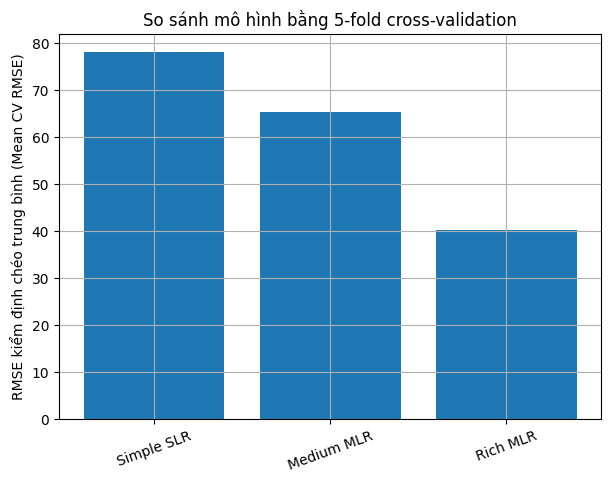

In [19]:
plt.figure()
plt.bar(cv_results['model'], cv_results['cv_rmse_mean'])
plt.ylabel('RMSE kiểm định chéo trung bình (Mean CV RMSE)')
plt.title('So sánh mô hình bằng 5-fold cross-validation')
plt.xticks(rotation=20)
plt.show()

# Hoạt động 7 - Overfitting và hồi quy đa thức (Polynomial Regression)

Polynomial regression vẫn là hồi quy tuyến tính vì mô hình tuyến tính theo hệ số $\beta$:

$$y = \beta_0 + \beta_1x + \beta_2x^2 + \cdots + \beta_dx^d + \varepsilon$$

Khi bậc $d$ tăng, mô hình linh hoạt hơn. Training error thường giảm, nhưng test error có thể tăng do overfitting.

In [20]:
df_poly = pd.read_csv(DATA_DIR / 'activity_05_polynomial_overfitting.csv')
train = df_poly[df_poly['split'] == 'train']
test = df_poly[df_poly['split'] == 'test']

results = []
for degree in range(1, 16):
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('linreg', LinearRegression())
    ])
    pipe.fit(train[['x']], train['y'])
    pred_train = pipe.predict(train[['x']])
    pred_test = pipe.predict(test[['x']])
    results.append({
        'degree': degree,
        'train_rmse': np.sqrt(mean_squared_error(train['y'], pred_train)),
        'test_rmse': np.sqrt(mean_squared_error(test['y'], pred_test))
    })

res = pd.DataFrame(results)
res

,degree,train_rmse,test_rmse
0,1,3.262195,3.018022
1,2,2.724126,2.340791
2,3,2.214906,1.851142
3,4,2.213137,1.858954
4,5,2.198341,1.865068
5,6,2.155461,1.981993
6,7,2.144031,2.000173
7,8,2.140991,2.015372
8,9,2.134878,2.029109
9,10,2.133429,2.021403


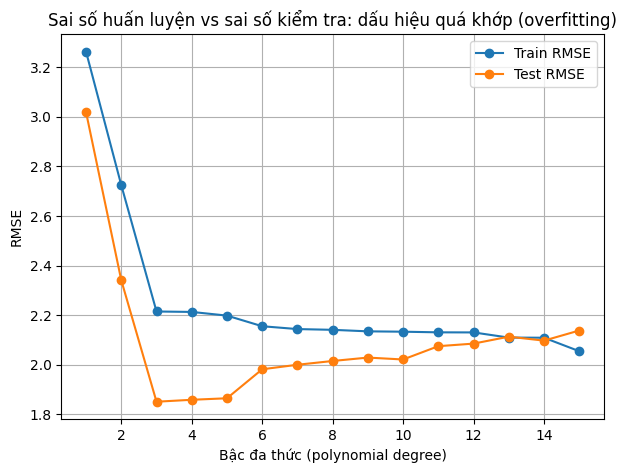

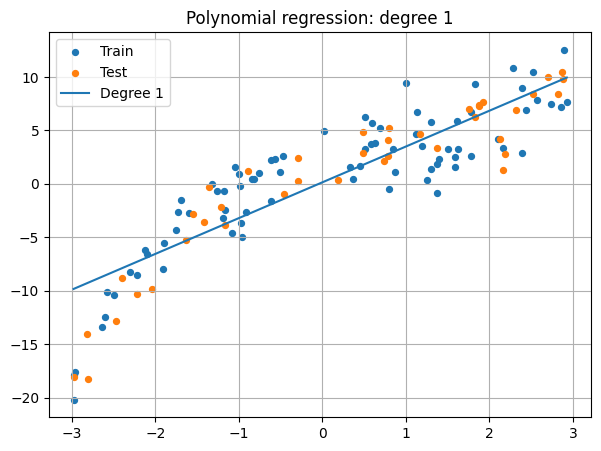

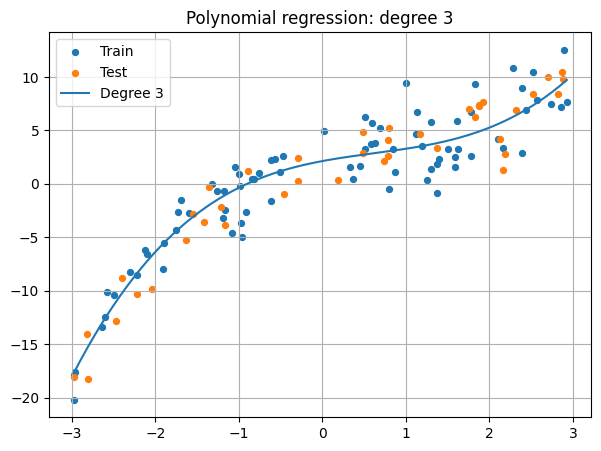

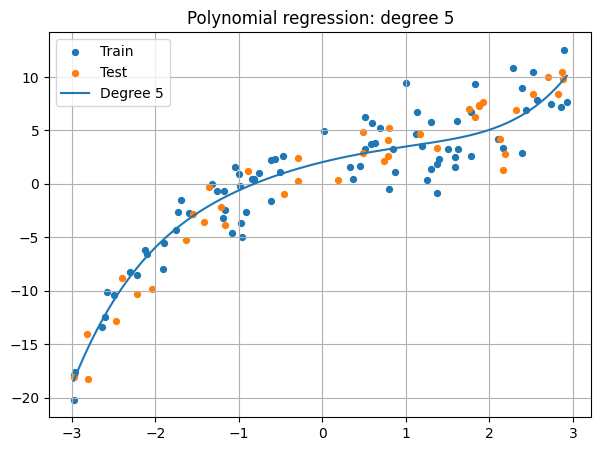

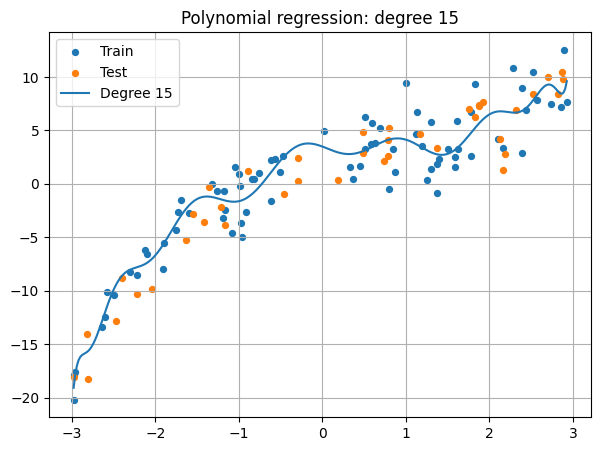

In [21]:
plt.figure()
plt.plot(res['degree'], res['train_rmse'], marker='o', label='Train RMSE')
plt.plot(res['degree'], res['test_rmse'], marker='o', label='Test RMSE')
plt.xlabel('Bậc đa thức (polynomial degree)')
plt.ylabel('RMSE')
plt.title('Sai số huấn luyện vs sai số kiểm tra: dấu hiệu quá khớp (overfitting)')
plt.legend()
plt.show()

x_grid = np.linspace(df_poly['x'].min(), df_poly['x'].max(), 300).reshape(-1, 1)
for degree in [1, 3, 5, 15]:
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('linreg', LinearRegression())
    ])
    pipe.fit(train[['x']], train['y'])
    plt.figure()
    plt.scatter(train['x'], train['y'], s=18, label='Train')
    plt.scatter(test['x'], test['y'], s=18, label='Test')
    plt.plot(x_grid.ravel(), pipe.predict(pd.DataFrame({'x': x_grid.ravel()})), label=f'Degree {degree}')
    plt.title(f'Polynomial regression: degree {degree}')
    plt.legend()
    plt.show()

# Hoạt động 8 - Chính quy hóa (Regularization): Ridge, Lasso, Elastic Net

Ridge:

$$\min_\beta \left[\sum_i(y_i-\hat y_i)^2 + \lambda\sum_j\beta_j^2\right]$$

Lasso:

$$\min_\beta \left[\sum_i(y_i-\hat y_i)^2 + \lambda\sum_j|\beta_j|\right]$$

Elastic Net kết hợp L1 và L2 penalty.

Cần chuẩn hóa predictors trước regularization vì penalty phụ thuộc vào độ lớn hệ số.

### Vì sao cần chính quy hóa (regularization)?

Khi có nhiều biến giải thích, đặc biệt là khi các biến tương quan mạnh với nhau, hệ số OLS có thể dao động mạnh. Chính quy hóa thêm một khoản phạt vào hàm mất mát để đánh đổi một chút độ khớp trên tập huấn luyện lấy mô hình ổn định hơn.

- **Ridge regression**: phạt bình phương hệ số, thường co hệ số về gần 0 nhưng không bằng 0.
- **Lasso regression**: phạt trị tuyệt đối của hệ số, có thể đưa một số hệ số về đúng 0.
- **Elastic Net**: kết hợp Ridge và Lasso.


In [22]:
df_reg = pd.read_csv(DATA_DIR / 'activity_06_high_dimensional_regularization.csv')
feature_cols = [c for c in df_reg.columns if c.startswith('x')]
train = df_reg[df_reg['split'] == 'train']
test = df_reg[df_reg['split'] == 'test']

X_train, y_train = train[feature_cols], train['target']
X_test, y_test = test[feature_cols], test['target']

models = {
    'OLS': Pipeline([('scale', StandardScaler()), ('model', LinearRegression())]),
    'RidgeCV': Pipeline([('scale', StandardScaler()), ('model', RidgeCV(alphas=np.logspace(-3, 3, 60)))]),
    'LassoCV': Pipeline([('scale', StandardScaler()), ('model', LassoCV(alphas=np.logspace(-3, 1, 60), max_iter=20000))]),
    'ElasticNetCV': Pipeline([('scale', StandardScaler()), ('model', ElasticNetCV(alphas=np.logspace(-3, 1, 40), l1_ratio=[.1, .3, .5, .7, .9], max_iter=20000))])
}

rows = []
for name, m in models.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    metrics = regression_metrics(y_test, pred)
    coef = m.named_steps['model'].coef_
    rows.append({'model': name, **metrics, 'nonzero_coef': int(np.sum(np.abs(coef) > 1e-8))})

pd.DataFrame(rows)

,model,RMSE,MAE,R2,nonzero_coef
0,OLS,4.980296,4.088460,0.653198,25
1,RidgeCV,4.937397,4.058310,0.659147,25
2,LassoCV,4.601549,3.668801,0.703940,13
3,ElasticNetCV,4.664870,3.724901,0.695736,16


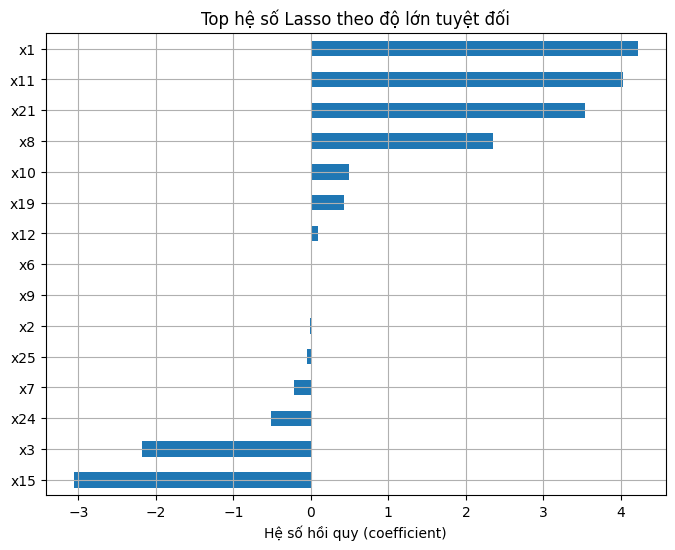

x1     4.214146
x11    4.027232
x21    3.531533
x15   -3.056193
x8     2.343772
x3    -2.171435
x24   -0.518411
x10    0.491379
x19    0.429517
x7    -0.214326
dtype: float64

In [23]:
# Biểu đồ hệ số (coefficient plot) cho Lasso: hệ số bằng 0 nghĩa là biến bị loại khỏi mô hình.
lasso = models['LassoCV']
coef = pd.Series(lasso.named_steps['model'].coef_, index=feature_cols)
coef_sorted = coef.sort_values(key=np.abs, ascending=False)

plt.figure(figsize=(8, 6))
coef_sorted.head(15).sort_values().plot(kind='barh')
plt.title('Top hệ số Lasso theo độ lớn tuyệt đối')
plt.xlabel('Hệ số hồi quy (coefficient)')
plt.show()

coef_sorted.head(10)

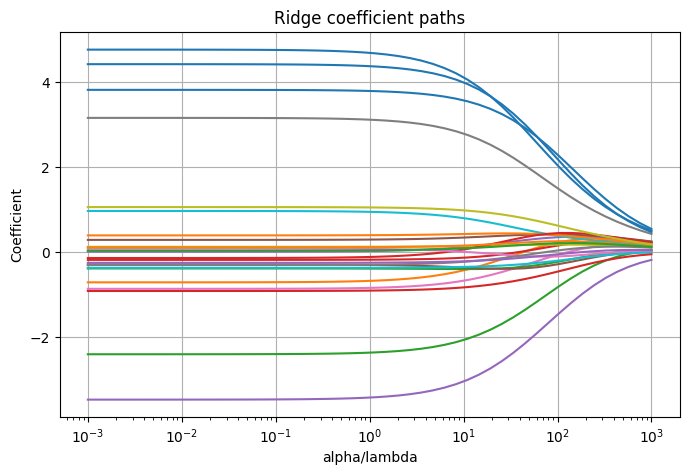

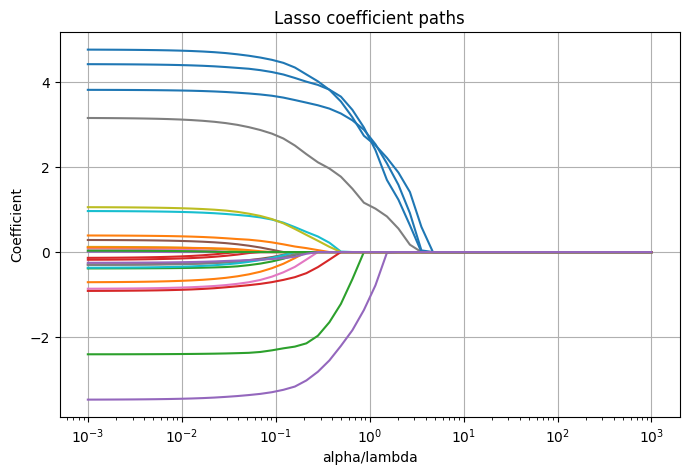

In [24]:
# Coefficient path đơn giản cho Ridge và Lasso theo alpha/lambda.
alphas = np.logspace(-3, 3, 50)
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)

ridge_coefs, lasso_coefs = [], []
for a in alphas:
    ridge = Ridge(alpha=a).fit(X_train_scaled, y_train)
    lasso_path_model = Lasso(alpha=a, max_iter=20000).fit(X_train_scaled, y_train)
    ridge_coefs.append(ridge.coef_)
    lasso_coefs.append(lasso_path_model.coef_)

plt.figure(figsize=(8, 5))
plt.plot(alphas, np.array(ridge_coefs))
plt.xscale('log')
plt.xlabel('alpha/lambda')
plt.ylabel('Coefficient')
plt.title('Ridge coefficient paths')
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(alphas, np.array(lasso_coefs))
plt.xscale('log')
plt.xlabel('alpha/lambda')
plt.ylabel('Coefficient')
plt.title('Lasso coefficient paths')
plt.show()

# Hoạt động 9 - Kịch bản phi tuyến nâng cao (Advanced Nonlinear Scenario)

Tác động quảng cáo thường có dạng bão hòa (saturation): tăng ngân sách ban đầu giúp nhiều, nhưng sau đó lợi ích biên giảm.

Ta có thể giữ mô hình tuyến tính theo hệ số bằng cách biến đổi feature:

$$\log(1 + \text{ad\_spend\_k})$$

Mùa vụ có thể mã hóa bằng cặp biến sine/cosine:

$$\sin\left(\frac{2\pi\cdot month}{12}\right),\quad \cos\left(\frac{2\pi\cdot month}{12}\right)$$

In [25]:
df_mkt = pd.read_csv(DATA_DIR / 'activity_07_advanced_nonlinear_marketing.csv')
df_mkt.head()

,week_id,ad_spend_k,discount_rate,competitor_price_index,month,website_visits,sales_units,true_ad_effect_is_saturating
0,1,79.15,0.182,122.96,12,7719,1207.9,yes
1,2,17.92,0.175,88.09,12,3679,832.6,yes
2,3,45.75,0.226,112.86,12,5359,1087.7,yes
3,4,13.13,0.160,87.97,8,1663,719.7,yes
4,5,18.81,0.197,104.46,6,2074,768.0,yes


In [26]:
# Tạo đặc trưng (feature engineering): tạo biến mới để mô hình hóa mẫu hình phi tuyến.
df_mkt['log_ad_spend'] = np.log1p(df_mkt['ad_spend_k'])
df_mkt['ad_discount_interaction'] = df_mkt['log_ad_spend'] * df_mkt['discount_rate']
df_mkt['month_sin'] = np.sin(2*np.pi*df_mkt['month']/12)
df_mkt['month_cos'] = np.cos(2*np.pi*df_mkt['month']/12)

features_raw = ['ad_spend_k', 'discount_rate', 'competitor_price_index', 'website_visits']
features_improved = ['log_ad_spend', 'discount_rate', 'ad_discount_interaction', 'competitor_price_index', 'website_visits', 'month_sin', 'month_cos']

def fit_compare(data, features):
    X_train, X_test, y_train, y_test = train_test_split(data[features], data['sales_units'], test_size=.25, random_state=42)
    model = LinearRegression().fit(X_train, y_train)
    pred = model.predict(X_test)
    return model, regression_metrics(y_test, pred), (X_test, y_test, pred)

raw_model, raw_metrics, raw_eval = fit_compare(df_mkt, features_raw)
improved_model, improved_metrics, improved_eval = fit_compare(df_mkt, features_improved)
print('Raw linear model:', raw_metrics)
print('Improved feature-engineered model:', improved_metrics)

Raw linear model: {'RMSE': np.float64(63.23655059179615), 'MAE': 47.363884706067, 'R2': 0.886110754842227}
Improved feature-engineered model: {'RMSE': np.float64(49.844638495229574), 'MAE': 40.44114115990752, 'R2': 0.9292407417993347}


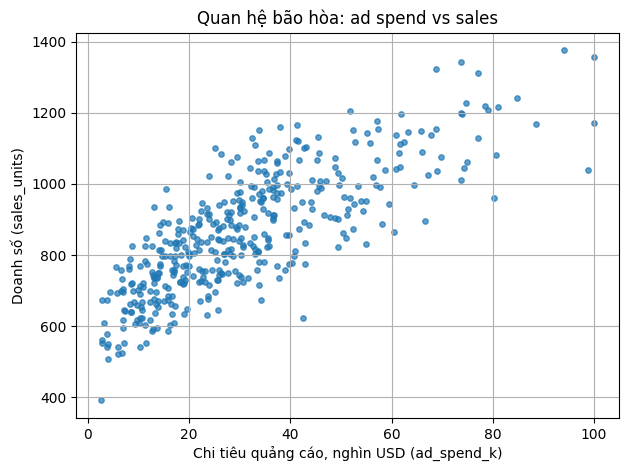

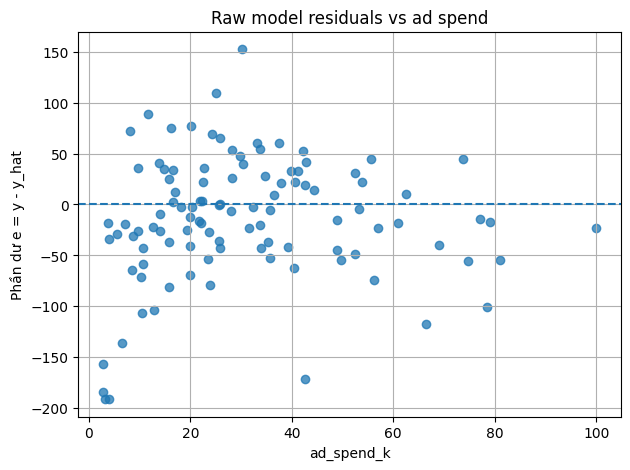

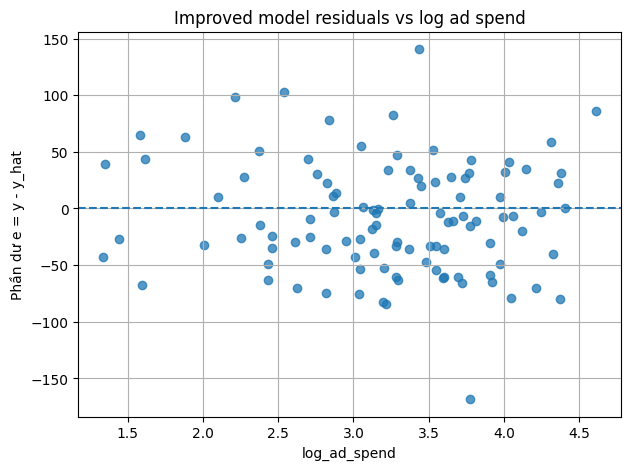

In [27]:
plt.figure()
plt.scatter(df_mkt['ad_spend_k'], df_mkt['sales_units'], s=15, alpha=0.7)
plt.xlabel('Chi tiêu quảng cáo, nghìn USD (ad_spend_k)')
plt.ylabel('Doanh số (sales_units)')
plt.title('Quan hệ bão hòa: ad spend vs sales')
plt.show()

# Residual plot trước và sau feature engineering
raw_X_test, raw_y_test, raw_pred = raw_eval
imp_X_test, imp_y_test, imp_pred = improved_eval
plot_residuals(raw_X_test['ad_spend_k'], raw_y_test - raw_pred, xlabel='ad_spend_k', title='Raw model residuals vs ad spend')
plot_residuals(imp_X_test['log_ad_spend'], imp_y_test - imp_pred, xlabel='log_ad_spend', title='Improved model residuals vs log ad spend')

# Hoạt động 10 - Robust, Weighted và Quantile Regression

OLS dùng squared loss:

$$L(e)=e^2$$

Vì bình phương lỗi, outlier có thể ảnh hưởng rất mạnh. Các lựa chọn thay thế:

- **Robust regression**: giảm ảnh hưởng của residual rất lớn.
- **Weighted Least Squares (WLS)**: dùng trọng số khi phương sai lỗi khác nhau.
- **Quantile regression**: mô hình hóa phân vị, ví dụ median hoặc percentile 90, thay vì mean.

OLS {'RMSE': np.float64(3321.3776197580614), 'MAE': 2241.1232584118234, 'R2': 0.2900170028731893}


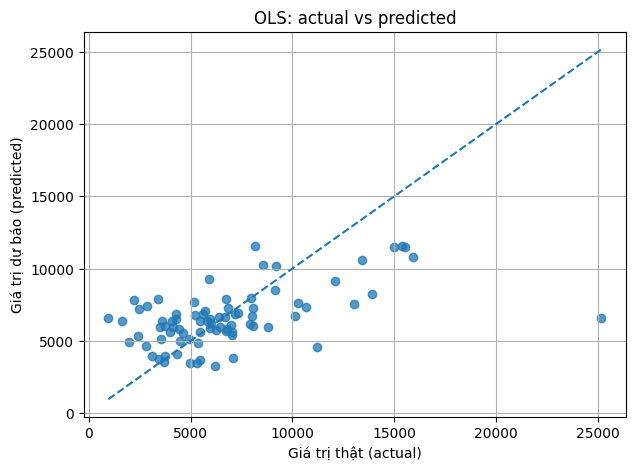

Huber robust {'RMSE': np.float64(3343.387957889351), 'MAE': 2221.632822759446, 'R2': 0.280575893450704}


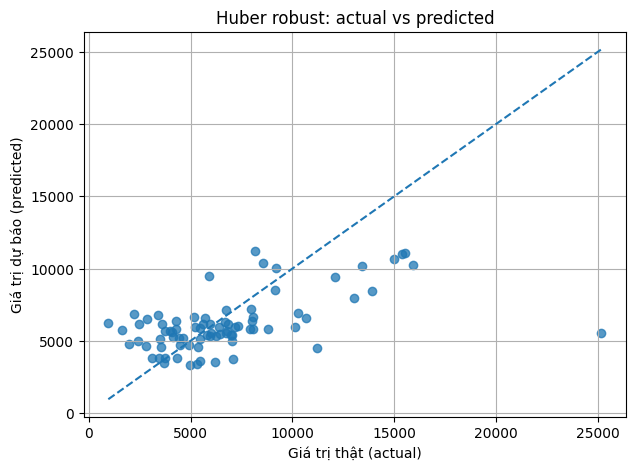

In [28]:
df_med = pd.read_csv(DATA_DIR / 'activity_08_robust_weighted_quantile.csv')
num = ['age', 'bmi', 'smoker']
cat = ['exercise_level']
X = df_med[num + cat]
y = df_med['annual_cost_usd']

pre = ColumnTransformer([
    ('num', StandardScaler(), num),
    ('cat', make_one_hot(drop='first'), cat)
])

ols = Pipeline([('pre', pre), ('model', LinearRegression())])
huber = Pipeline([('pre', pre), ('model', HuberRegressor(max_iter=1000))])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.25, random_state=42)
for name, m in [('OLS', ols), ('Huber robust', huber)]:
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    print(name, regression_metrics(y_test, pred))
    actual_vs_predicted(y_test, pred, title=f'{name}: actual vs predicted')

<Figure size 700x500 with 0 Axes>

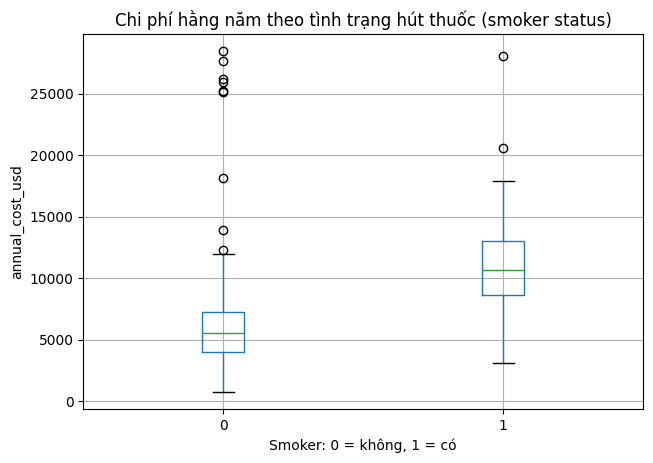

Median/0.5 quantile regression
                         QuantReg Regression Results                          
Dep. Variable:        annual_cost_usd   Pseudo R-squared:               0.2051
Model:                       QuantReg   Bandwidth:                       1762.
Method:                 Least Squares   Sparsity:                        6192.
Date:                Tue, 05 May 2026   No. Observations:                  320
Time:                        02:24:39   Df Residuals:                      314
                                        Df Model:                            5
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                     454.6337   1206.638      0.377      0.707   -1919.484    2828.752
C(exercise_level)[T.low]     1822.0304    501.510      3.633      0.000     835.286    2808.775
C(exercise_level)[T.medium]  171

In [29]:
# Visualization: chi phí theo smoker status.
plt.figure()
df_med.boxplot(column='annual_cost_usd', by='smoker')
plt.suptitle('')
plt.title('Chi phí hằng năm theo tình trạng hút thuốc (smoker status)')
plt.xlabel('Smoker: 0 = không, 1 = có')
plt.ylabel('annual_cost_usd')
plt.show()

# Optional quantile regression bằng statsmodels nếu có.
try:
    import statsmodels.formula.api as smf
    q50 = smf.quantreg('annual_cost_usd ~ age + bmi + smoker + C(exercise_level)', data=df_med).fit(q=0.5)
    q90 = smf.quantreg('annual_cost_usd ~ age + bmi + smoker + C(exercise_level)', data=df_med).fit(q=0.9)
    print('Median/0.5 quantile regression')
    print(q50.summary())
    print('\n0.9 quantile regression')
    print(q90.summary())
except Exception as e:
    print('Không chạy được quantile regression do statsmodels hoặc hội tụ:', e)

# Hoạt động 11 - Capstone Regression Challenge

Dataset: `activity_09_capstone_regression_challenge.csv`

Sinh viên cần tự xây dựng quy trình:

1. Câu hỏi nghiên cứu (research question)
2. Tổng quan dữ liệu và EDA
3. Baseline SLR
4. MLR
5. Diagnostics
6. Mô hình cải tiến: transformations, interactions, regularization hoặc nonlinear alternatives
7. Train/test performance
8. Diễn giải key predictors
9. Limitations và recommendations

Yêu cầu visualization tối thiểu:

- 3 EDA plots
- residual plot
- actual vs predicted plot
- model comparison chart
- coefficient plot hoặc feature-importance visualization

In [30]:
df_capstone = pd.read_csv(DATA_DIR / 'activity_09_capstone_regression_challenge.csv')
print(df_capstone.shape)
df_capstone.head()

(500, 9)


,home_id,size_sqft,age_years,distance_to_cbd_km,school_quality_index,crime_index,condition,price_k_usd,split
0,1,2853,22.3,6.89,7.45,1.64,excellent,530.4,train
1,2,1244,66.2,3.46,5.93,4.41,good,370.1,train
2,3,2344,17.0,32.63,6.74,0.97,good,290.4,test
3,4,2278,55.4,18.00,9.18,3.31,poor,342.1,train
4,5,1603,42.2,6.72,5.33,2.03,excellent,432.4,train
